# 📊 House Prices — Visualização & Storytelling
**Responsável:** Natalia Pianca
**Dataset:** [Kaggle - House Prices: Advanced Regression Techniques](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data)  
**Objetivo:** Construir visualizações que contam a história dos dados e dos resultados do projeto.

---

##  0. Importações e Configuração Visual

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

# Estilo padrão dos gráficos
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


##  1. Carregamento dos Dados

In [2]:

df = pd.read_csv(r"../data/train.csv")
# df = pd.read_csv('data/train.csv')     trocar o caminho para o dataset
print(f'Shape do dataset: {df.shape}')
print(f'Colunas: {df.shape[1]} | Linhas: {df.shape[0]}')
df.head()

Shape do dataset: (1460, 81)
Colunas: 81 | Linhas: 1460


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


---
##  Storytelling — Parte 1: Conhecendo os Dados

> Antes de construir qualquer modelo, precisamos entender **o que os dados nos contam**.
> O dataset contém informações sobre casas vendidas em Ames, Iowa (EUA), com dezenas de características
> como tamanho, qualidade, localização e ano de construção.
> Nossa variável-alvo é o **SalePrice** — o preço final de venda de cada casa.

##  2. Distribuições das Variáveis Principais

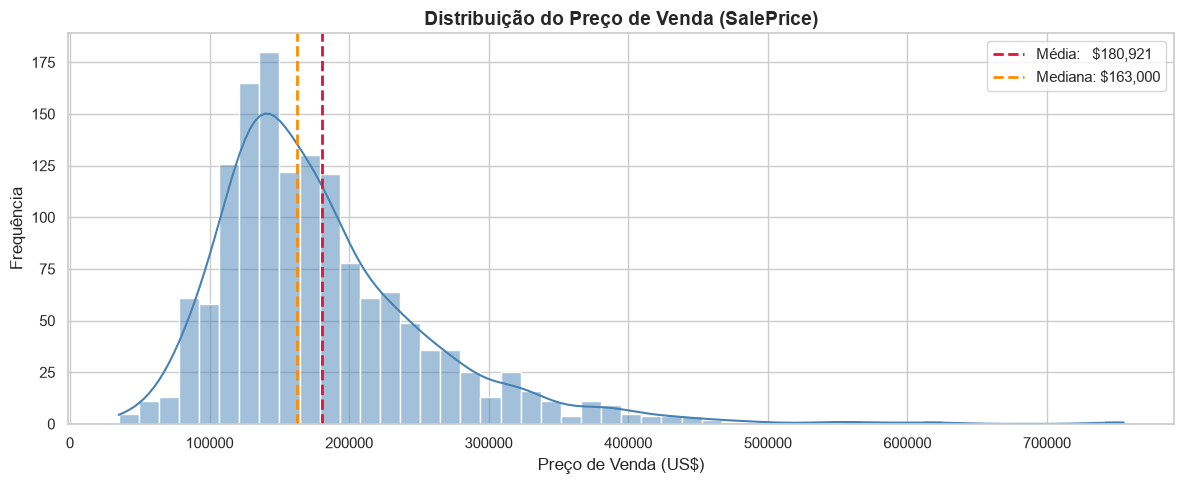

✅ Gráfico salvo!


In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=50, ax=ax)

ax.axvline(df['SalePrice'].mean(),   color='crimson',    linestyle='--', linewidth=2, label=f"Média:   ${df['SalePrice'].mean():,.0f}")
ax.axvline(df['SalePrice'].median(), color='darkorange', linestyle='--', linewidth=2, label=f"Mediana: ${df['SalePrice'].median():,.0f}")

ax.set_title('Distribuição do Preço de Venda (SalePrice)', fontsize=14, fontweight='bold')
ax.set_xlabel('Preço de Venda (US$)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_distribuicao_saleprice.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

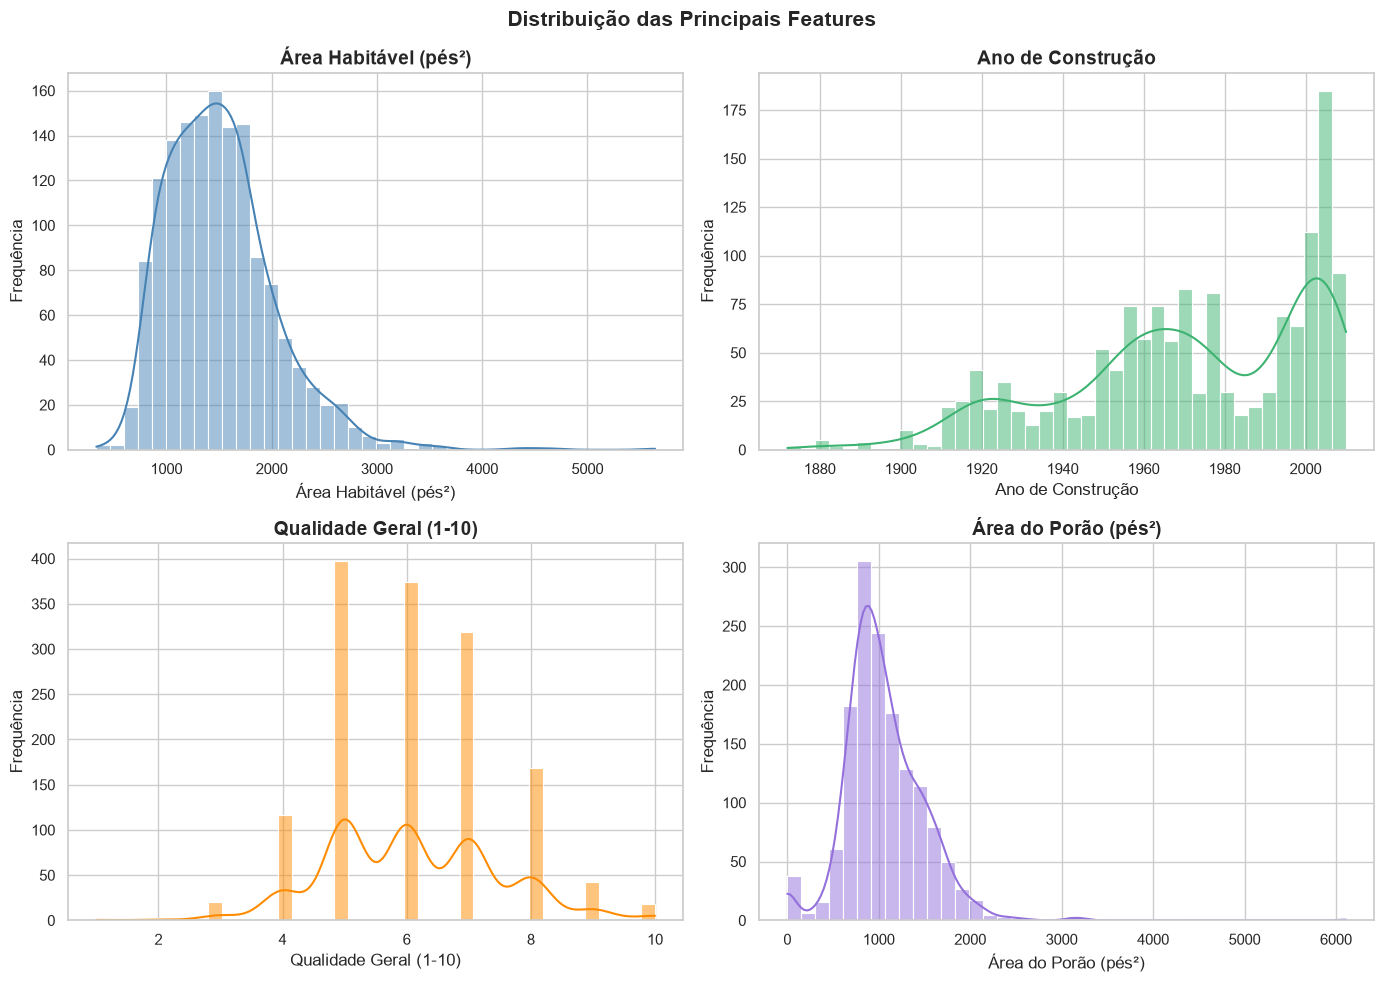

✅ Gráfico salvo!


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

features = {
    'GrLivArea':    'Área Habitável (pés²)',
    'YearBuilt':    'Ano de Construção',
    'OverallQual':  'Qualidade Geral (1-10)',
    'TotalBsmtSF':  'Área do Porão (pés²)'
}

cores = ['steelblue', 'mediumseagreen', 'darkorange', 'mediumpurple']

for ax, (col, label), cor in zip(axes.flatten(), features.items(), cores):
    sns.histplot(df[col].dropna(), kde=True, color=cor, bins=40, ax=ax)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequência')

plt.suptitle('Distribuição das Principais Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_distribuicoes_features.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
##  Storytelling — Parte 2: O Preço das Casas

> O preço de venda apresenta uma distribuição com **assimetria à direita** —
> a maioria das casas se concentra em faixas intermediárias, mas algumas casas de alto valor
> puxam a média para cima. Isso é típico do mercado imobiliário.

> *(Atualize este texto após gerar os gráficos com os valores reais encontrados)*

##  3. Heatmap de Correlações

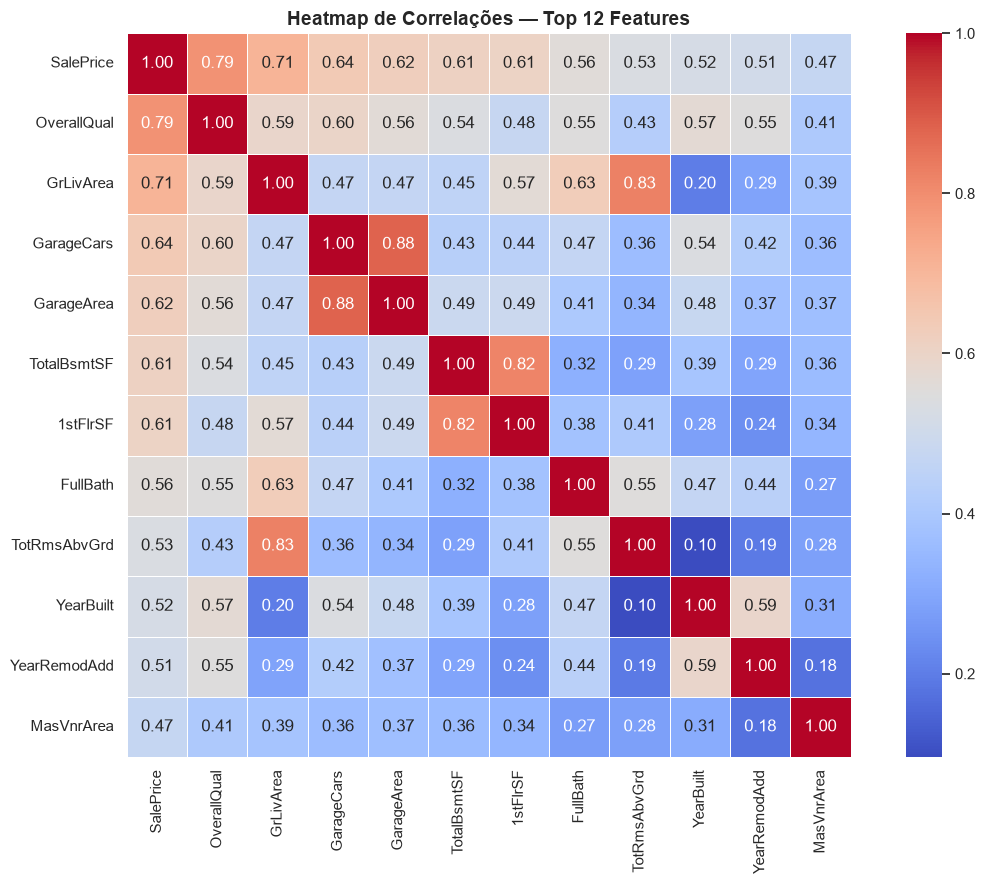

✅ Gráfico salvo!


In [5]:

df_num = df.select_dtypes(include=[np.number]).fillna(0)
top_corr = df_num.corr()['SalePrice'].abs().sort_values(ascending=False).head(12).index

fig, ax = plt.subplots(figsize=(12, 9))

sns.heatmap(
    df_num[top_corr].corr(),
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    ax=ax
)

ax.set_title('Heatmap de Correlações — Top 12 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/plot_heatmap_correlacoes.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
## Storytelling — Parte 3: O Que Mais Influencia o Preço?

> O heatmap revela que as variáveis com **maior correlação** com o preço de venda são:
> `OverallQual` (qualidade geral), `GrLivArea` (área habitável) e `GarageCars` (vagas na garagem).
> Isso faz sentido intuitivo: casas maiores, de melhor qualidade e com garagem valem mais.

> *(Atualize com as features reais após rodar o heatmap)*

##  4. Scatter Plots — Relação entre Features e Preço

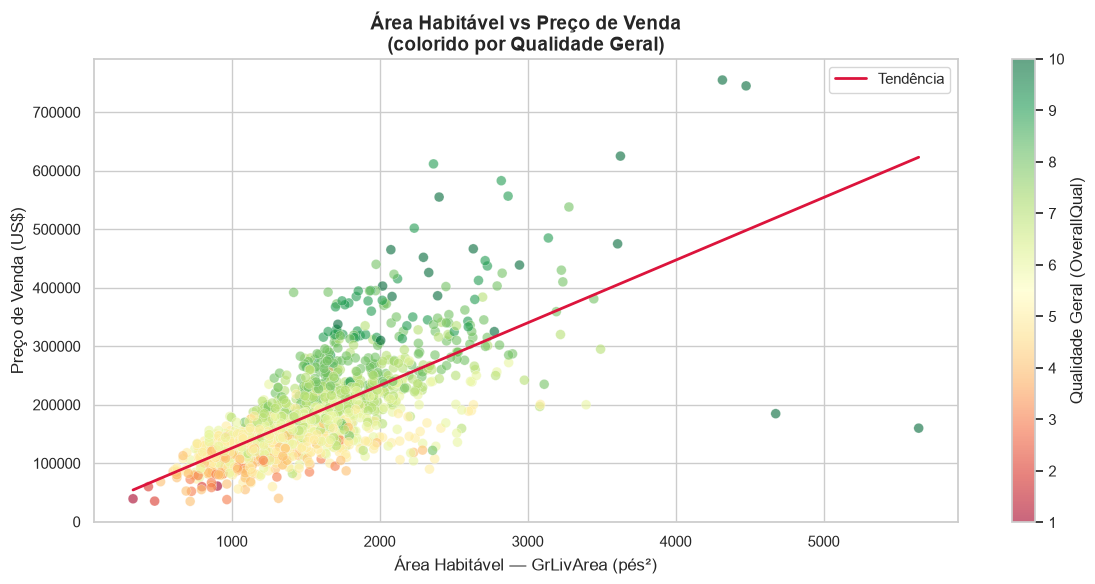

✅ Gráfico salvo!


In [6]:
fig, ax = plt.subplots(figsize=(12, 6))

scatter = ax.scatter(
    df['GrLivArea'],
    df['SalePrice'],
    c=df['OverallQual'],
    cmap='RdYlGn',
    alpha=0.6,
    edgecolors='white',
    linewidth=0.3,
    s=50
)

# Linha de tendência
m, b = np.polyfit(df['GrLivArea'], df['SalePrice'], 1)
x_line = np.linspace(df['GrLivArea'].min(), df['GrLivArea'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Tendência')

plt.colorbar(scatter, ax=ax, label='Qualidade Geral (OverallQual)')
ax.set_title('Área Habitável vs Preço de Venda\n(colorido por Qualidade Geral)', fontweight='bold')
ax.set_xlabel('Área Habitável — GrLivArea (pés²)')
ax.set_ylabel('Preço de Venda (US$)')
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_scatter_area_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

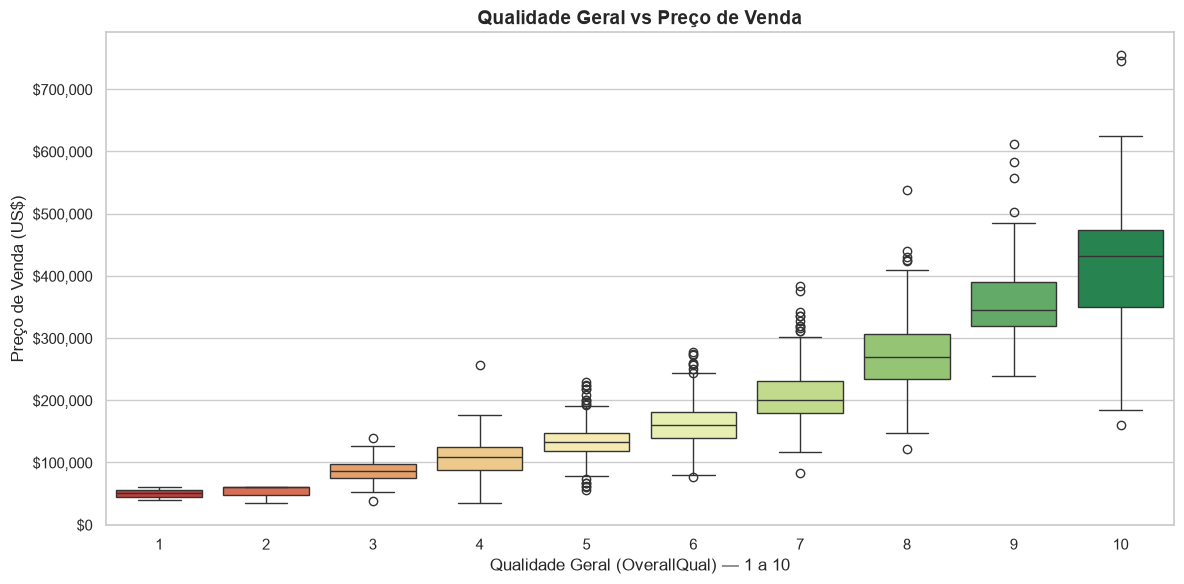

✅ Gráfico salvo!


In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='OverallQual',
    y='SalePrice',
    palette='RdYlGn',
    ax=ax
)

ax.set_title('Qualidade Geral vs Preço de Venda', fontweight='bold')
ax.set_xlabel('Qualidade Geral (OverallQual) — 1 a 10')
ax.set_ylabel('Preço de Venda (US$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../plots/plot_boxplot_qualidade_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

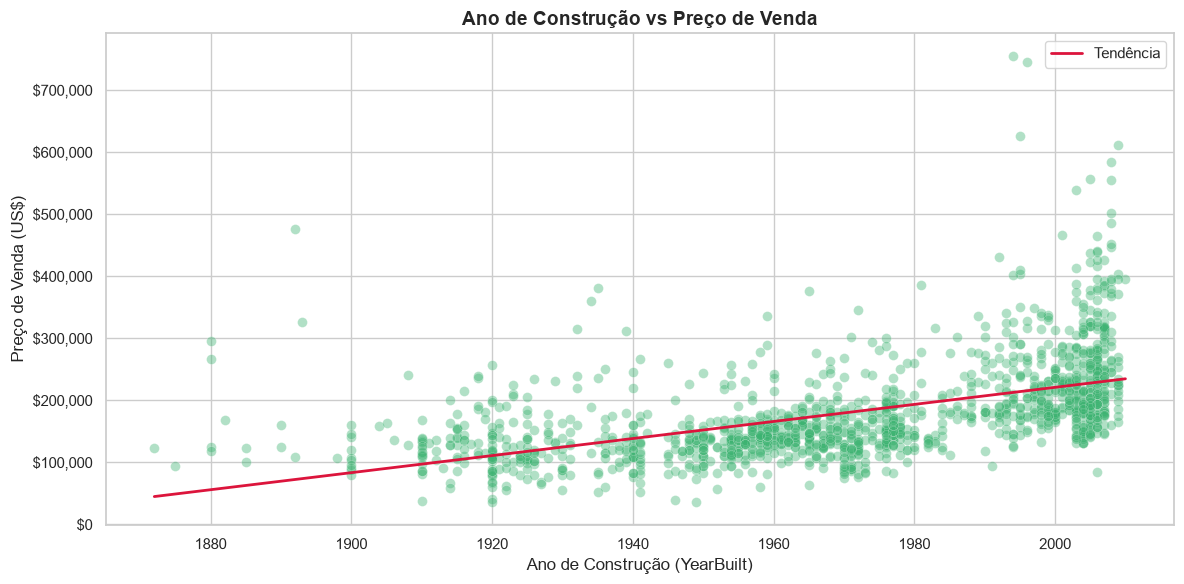

✅ Gráfico salvo!


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.scatter(
    df['YearBuilt'],
    df['SalePrice'],
    alpha=0.4,
    color='mediumseagreen',
    edgecolors='white',
    linewidth=0.3,
    s=50
)

# Linha de tendência
m, b = np.polyfit(df['YearBuilt'], df['SalePrice'], 1)
x_line = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 100)
ax.plot(x_line, m * x_line + b, color='crimson', linewidth=2, label='Tendência')

ax.set_title('Ano de Construção vs Preço de Venda', fontweight='bold')
ax.set_xlabel('Ano de Construção (YearBuilt)')
ax.set_ylabel('Preço de Venda (US$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()

plt.tight_layout()
plt.savefig('../plots/plot_scatter_ano_preco.png', dpi=150)
plt.show()
print('✅ Gráfico salvo!')

---
##  Storytelling — Parte 4: Padrões Visuais

> Os scatter plots confirmam o que a correlação indicava:
> - **Área habitável** tem relação linear positiva com o preço
> - **Qualidade geral** é talvez o fator mais determinante — casas de qualidade 9-10 chegam a valer 3x mais que as de qualidade 4-5
> - **Ano de construção** mostra que casas mais recentes tendem a ser mais caras, mas com maior variação

> *(Atualize com observações reais após rodar os gráficos)*

## 5. Painel Consolidado

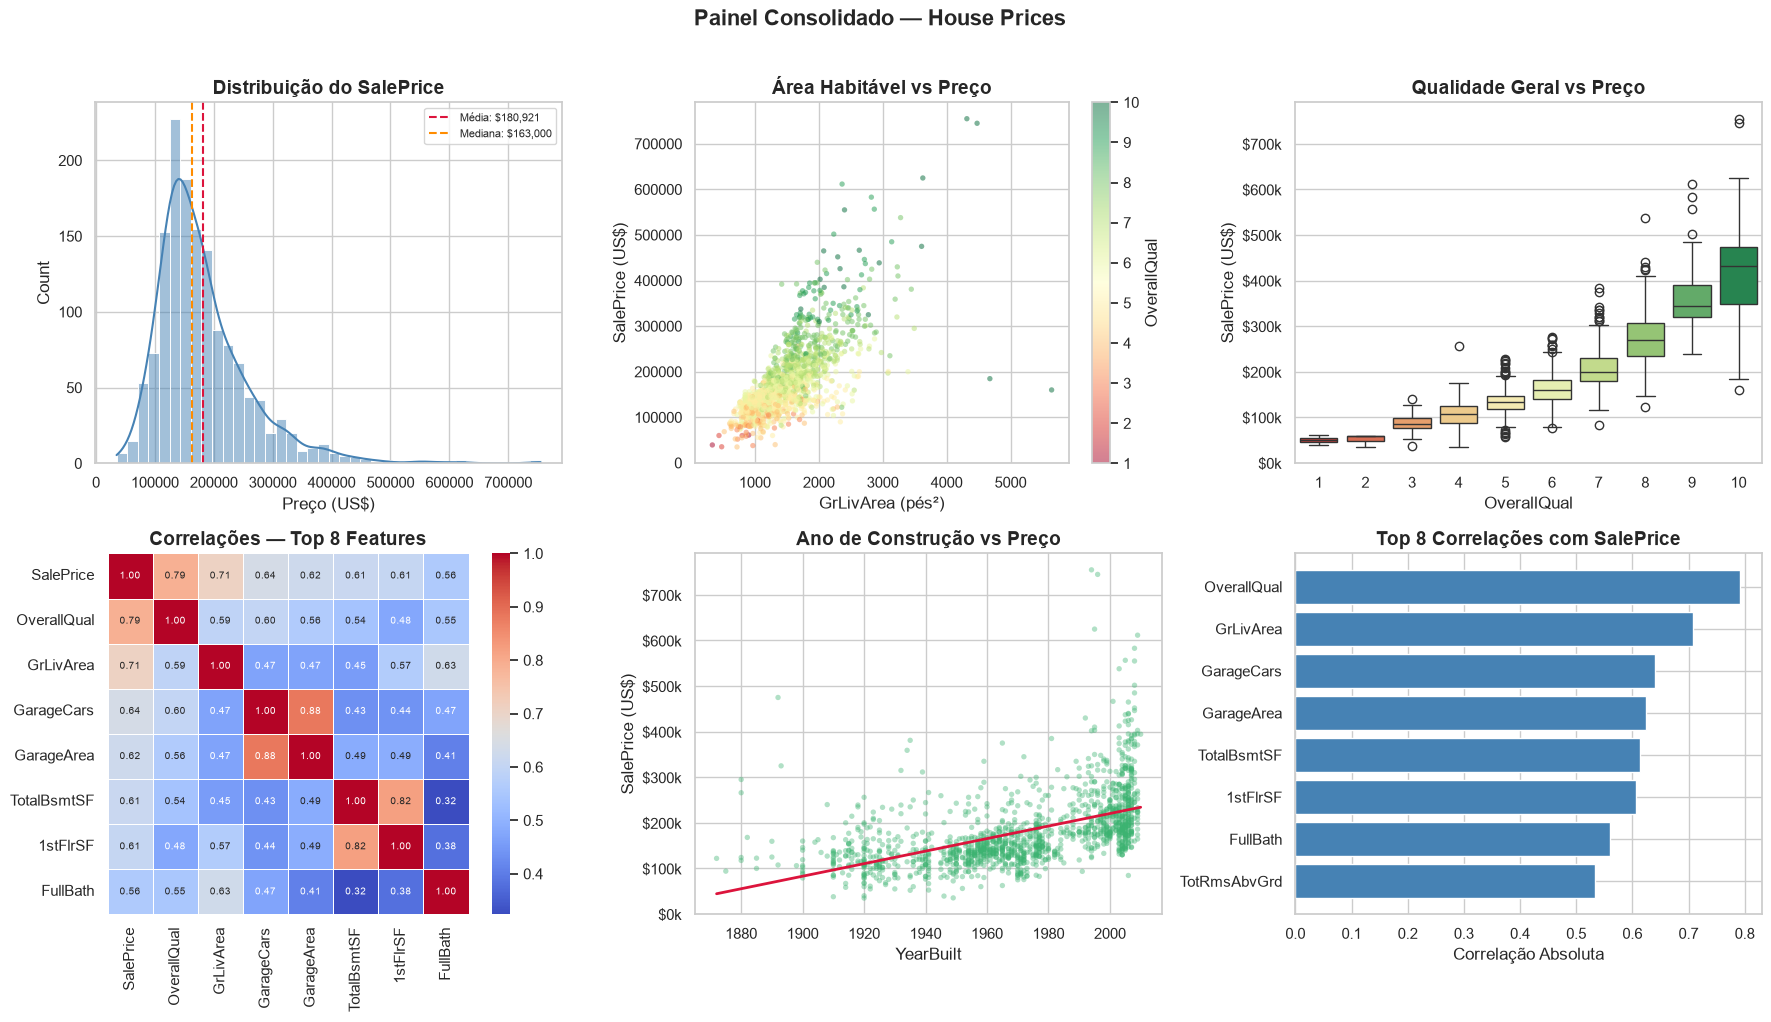

✅ Painel salvo!


In [9]:
fig = plt.figure(figsize=(18, 10))
fig.suptitle('Painel Consolidado — House Prices', fontsize=16, fontweight='bold', y=1.01)

# ── [0,0] Distribuição SalePrice ──
ax1 = fig.add_subplot(2, 3, 1)
sns.histplot(df['SalePrice'], kde=True, color='steelblue', bins=40, ax=ax1)
ax1.axvline(df['SalePrice'].mean(),   color='crimson',   linestyle='--', linewidth=1.5, label=f"Média: ${df['SalePrice'].mean():,.0f}")
ax1.axvline(df['SalePrice'].median(), color='darkorange', linestyle='--', linewidth=1.5, label=f"Mediana: ${df['SalePrice'].median():,.0f}")
ax1.set_title('Distribuição do SalePrice', fontweight='bold')
ax1.set_xlabel('Preço (US$)')
ax1.legend(fontsize=8)

# ── [0,1] Scatter GrLivArea x SalePrice ──
ax2 = fig.add_subplot(2, 3, 2)
sc = ax2.scatter(df['GrLivArea'], df['SalePrice'], c=df['OverallQual'],
                 cmap='RdYlGn', alpha=0.5, s=15, edgecolors='none')
plt.colorbar(sc, ax=ax2, label='OverallQual')
ax2.set_title('Área Habitável vs Preço', fontweight='bold')
ax2.set_xlabel('GrLivArea (pés²)')
ax2.set_ylabel('SalePrice (US$)')

# ── [0,2] Boxplot OverallQual ──
ax3 = fig.add_subplot(2, 3, 3)
sns.boxplot(data=df, x='OverallQual', y='SalePrice', palette='RdYlGn', ax=ax3)
ax3.set_title('Qualidade Geral vs Preço', fontweight='bold')
ax3.set_xlabel('OverallQual')
ax3.set_ylabel('SalePrice (US$)')
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── [1,0] Heatmap mini ──
ax4 = fig.add_subplot(2, 3, 4)
top8 = df.select_dtypes(include=[np.number]).fillna(0).corr()['SalePrice'].abs().sort_values(ascending=False).head(8).index
sns.heatmap(df[top8].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5, ax=ax4, annot_kws={'size': 7})
ax4.set_title('Correlações — Top 8 Features', fontweight='bold')

# ── [1,1] Scatter YearBuilt ──
ax5 = fig.add_subplot(2, 3, 5)
ax5.scatter(df['YearBuilt'], df['SalePrice'], alpha=0.4, color='mediumseagreen', s=15, edgecolors='none')
m, b = np.polyfit(df['YearBuilt'], df['SalePrice'], 1)
x_line = np.linspace(df['YearBuilt'].min(), df['YearBuilt'].max(), 100)
ax5.plot(x_line, m * x_line + b, color='crimson', linewidth=2)
ax5.set_title('Ano de Construção vs Preço', fontweight='bold')
ax5.set_xlabel('YearBuilt')
ax5.set_ylabel('SalePrice (US$)')
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# ── [1,2] Correlações com SalePrice (barras) ──
ax6 = fig.add_subplot(2, 3, 6)
top_corr = df.select_dtypes(include=[np.number]).fillna(0).corr()['SalePrice'].drop('SalePrice').abs().sort_values(ascending=False).head(8)
colors = ['steelblue' if v > 0 else 'crimson' for v in top_corr]
ax6.barh(top_corr.index[::-1], top_corr.values[::-1], color=colors[::-1])
ax6.set_title('Top 8 Correlações com SalePrice', fontweight='bold')
ax6.set_xlabel('Correlação Absoluta')

plt.tight_layout()
plt.savefig('../plots/plot_painel_consolidado.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Painel salvo!')

---
## Storytelling — Conclusão Final

### O que aprendemos com os dados?

Ao longo deste projeto, exploramos um dataset com **81 variáveis** sobre **1.460 casas** 
vendidas em Ames, Iowa (EUA). A análise revelou que o preço de uma casa é determinado 
principalmente por:

1. **Qualidade geral da construção (OverallQual)** — correlação de 0.79 com o preço, 
   o fator mais determinante isolado. Casas nota 10 valem em média ~$430k, quase 9x 
   mais que casas nota 1 (~$50k).
2. **Tamanho da área habitável (GrLivArea)** — correlação de 0.71, relação linear clara. 
   Quanto maior a casa, maior o preço.
3. **Garagem (GarageCars / GarageArea)** — correlação de 0.64, casas com mais vagas 
   tendem a ser mais caras.
4. **Ano de construção (YearBuilt)** — casas mais novas valem mais, com variação 
   crescente no mercado pós-2000.

O preço médio de venda foi de **$180,921**, com mediana de **$163,000** — a diferença 
indica a presença de casas de alto valor puxando a média para cima.

Os modelos supervisionados confirmaram esses padrões, com a **Regressão Múltipla** 
superando a simples em todas as métricas (MAE, RMSE e R²).
A clusterização identificou perfis distintos de imóveis, e a detecção de outliers 
revelou casos anômalos com características fora do padrão.

> falta *Preencher: resultados reais de MAE, RMSE e R² da Pessoa 1*  
> falta *Preencher: perfis dos clusters identificados pela Pessoa 3*  
> falta *Preencher: principais outliers encontrados pela Pessoa 4*

## 📁 Arquivos Gerados

| Arquivo | Descrição |
|---|---|
| `plot_distribuicao_saleprice.png` | Distribuição da variável alvo |
| `plot_distribuicoes_features.png` | Distribuição das principais features |
| `plot_heatmap_correlacoes.png` | Mapa de calor de correlações |
| `plot_scatter_area_preco.png` | Área habitável vs preço |
| `plot_boxplot_qualidade_preco.png` | Qualidade geral vs preço |
| `plot_scatter_ano_preco.png` | Ano de construção vs preço |
| `plot_painel_consolidado.png` | Painel completo do projeto |